<a href="https://colab.research.google.com/github/srijalgiri/Ai-ML_sem6/blob/main/2413995_Srijal_Giri_Code_Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 – Final Portfolio Assessment 2026
## Part III: Language Task – Fake News Detection
**Group:** Team A  
**Members:** Abhiral Pradhan, Srijal Giri, Prajwol Shrestha, Sadish Raj Pandey  

---
## Section 1: Setup & Data Loading

In [ ]:
# Install required libraries
!pip install -q numpy==1.23.5
!pip install -q gensim
!pip install -q gradio
!pip install -q wordcloud
!pip install -q contractions

import subprocess, sys
print('All packages installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 93.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.6 MB/s eta 0:00:00
All packages installed.


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, time, warnings, os
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('omw-1.4',   quiet=True)

from nltk.corpus   import stopwords
from nltk.stem     import WordNetLemmatizer
import contractions

from sklearn.model_selection import train_test_split
from sklearn.metrics         import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.preprocessing.text     import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras                         import layers, models
from tensorflow.keras.callbacks              import EarlyStopping, ReduceLROnPlateau

from wordcloud import WordCloud

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ── Load Dataset ─────────────────────────────────────────────────
# Change this path to wherever you uploaded the CSV in your Drive
CSV_PATH = '/content/drive/MyDrive/AI_Assessment/truevsfakenews.csv'
# ─────────────────────────────────────────────────────────────────

df = pd.read_csv(CSV_PATH)
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(3)

Shape: (20000, 2)
Columns: ['text', 'label']


,text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,true
1,Women should get as far away from Oklahoma as ...,fake
2,Another huge crowd of Americans tuned in last ...,fake


---
## Section 2: Text Preprocessing, EDA & Visualization

In [ ]:
# 2.1 – Basic info
print('Dataset Info:')
print(df.info())
print('\nLabel Distribution:')
print(df['label'].value_counts())
print('\nMissing values:')
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    20000 non-null  object
 1   label   20000 non-null  object
dtypes: object(2)
memory usage: 312.6+ KB
None

Label Distribution:
label
true    10000
fake    10000
Name: count, dtype: int64

Missing values:
text     0
label    0
dtype: int64


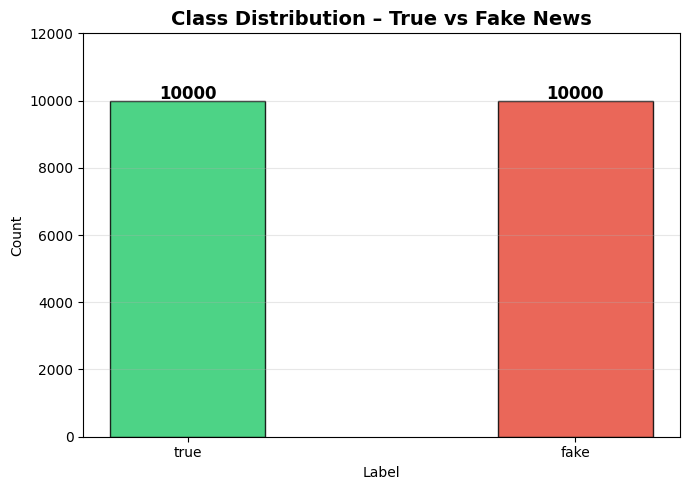

Dataset is balanced: equal true and fake samples.


In [ ]:
# 2.2 – Class Distribution Plot
label_counts = df['label'].value_counts()
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(label_counts.index, label_counts.values,
              color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.85, width=0.4)
for bar, val in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(val), ha='center', fontweight='bold', fontsize=12)
ax.set_title('Class Distribution – True vs Fake News', fontsize=14, fontweight='bold')
ax.set_xlabel('Label'); ax.set_ylabel('Count')
ax.set_ylim(0, 12000)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('nlp_class_distribution.png', dpi=150)
plt.show()
print('Dataset is balanced: equal true and fake samples.')

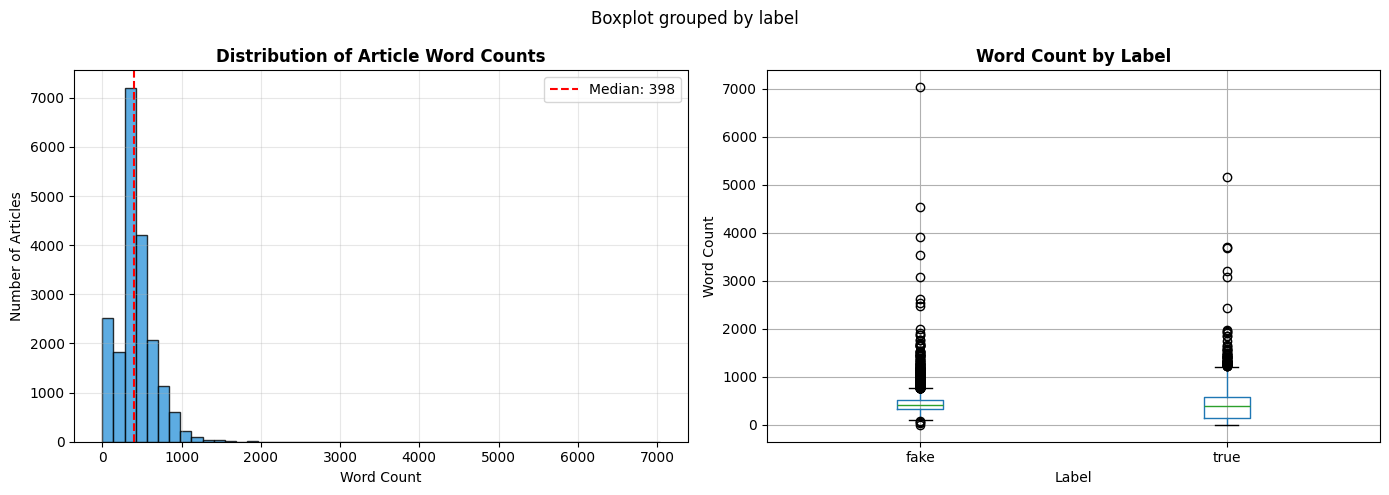

Mean: 426 | Median: 398 | Max: 7033


In [ ]:
# 2.3 – Article Word-Length Distribution
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['word_count'], bins=50, color='#3498db', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribution of Article Word Counts', fontweight='bold')
axes[0].set_xlabel('Word Count'); axes[0].set_ylabel('Number of Articles')
axes[0].axvline(df['word_count'].median(), color='red', linestyle='--', label=f"Median: {df['word_count'].median():.0f}")
axes[0].legend(); axes[0].grid(alpha=0.3)

df.boxplot(column='word_count', by='label', ax=axes[1])
axes[1].set_title('Word Count by Label', fontweight='bold')
axes[1].set_xlabel('Label'); axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.savefig('word_count_distribution.png', dpi=150)
plt.show()

print(f"Mean: {df['word_count'].mean():.0f} | Median: {df['word_count'].median():.0f} | Max: {df['word_count'].max()}")

In [ ]:
# 2.4 – Text Cleaning Function
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text)
    # Expand contractions
    text = contractions.fix(text)
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove special characters (keep letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in STOP_WORDS and len(w) > 2]
    return ' '.join(tokens)

print('Cleaning text... (may take ~1-2 minutes)')
t0 = time.time()
df['clean_text'] = df['text'].apply(clean_text)
print(f'Done in {time.time()-t0:.1f}s')

# Drop rows with empty clean text
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)
print('Remaining rows after cleaning:', len(df))
print('\nSample cleaned text:')
print(df['clean_text'].iloc[0][:300])

Cleaning text... (may take ~1-2 minutes)
Done in 32.0s
Remaining rows after cleaning: 19998

Sample cleaned text:
washington reuters republican democratic leader yous senate foreign relation committee blasted yous state department tuesday cut staff described failure plan proposed reorganization think anywhere close plan present relative reform want said senator bob corker republican chairman committee rex tille


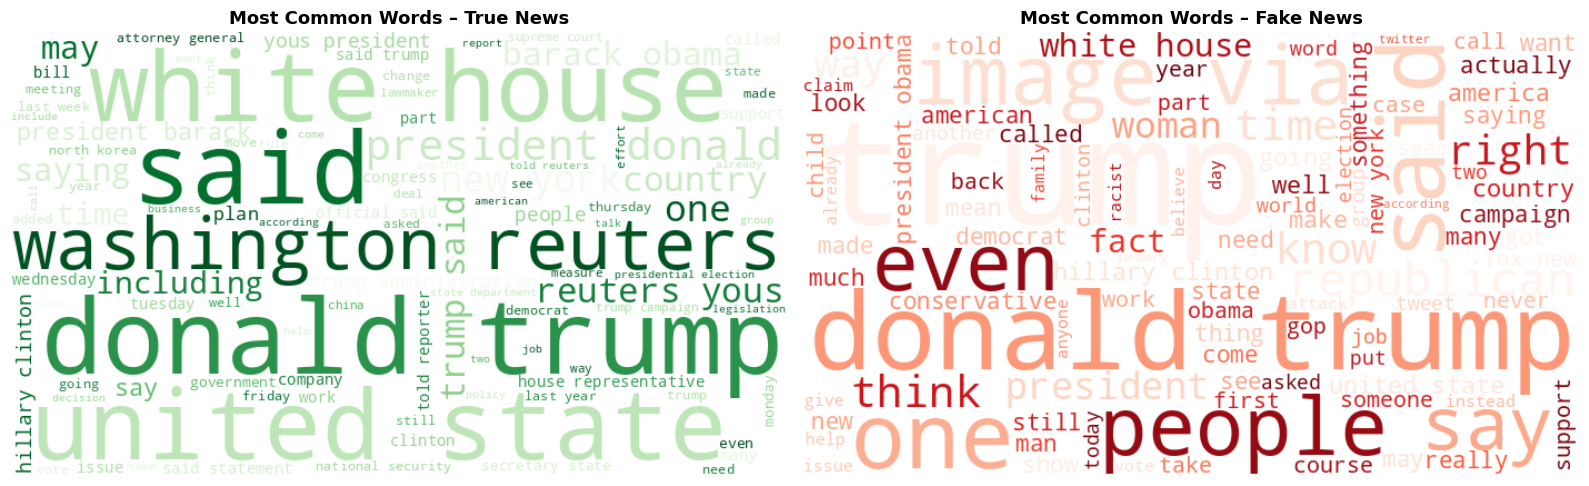

In [ ]:
# 2.5 – Word Cloud: True News
true_text = ' '.join(df[df['label']=='true']['clean_text'])
fake_text = ' '.join(df[df['label']=='fake']['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_true = WordCloud(width=700, height=400, background_color='white',
                    colormap='Greens', max_words=100).generate(true_text)
axes[0].imshow(wc_true, interpolation='bilinear')
axes[0].set_title('Most Common Words – True News', fontweight='bold', fontsize=13)
axes[0].axis('off')

wc_fake = WordCloud(width=700, height=400, background_color='white',
                    colormap='Reds', max_words=100).generate(fake_text)
axes[1].imshow(wc_fake, interpolation='bilinear')
axes[1].set_title('Most Common Words – Fake News', fontweight='bold', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150)
plt.show()

---
## Section 3: Tokenization & Sequence Padding

In [ ]:
# 3.1 – Encode labels: true=1, fake=0
df['label_encoded'] = (df['label'] == 'true').astype(int)
print('Label mapping: true=1, fake=0')
print(df['label_encoded'].value_counts())

Label mapping: true=1, fake=0
label_encoded
1    9999
0    9999
Name: count, dtype: int64


In [ ]:
# 3.2 – Train/Test Split (80/20)
X = df['clean_text'].values
y = df['label_encoded'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 15998 | Test: 4000


In [ ]:
# 3.3 – Tokenization
VOCAB_SIZE = 20000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

word_index = tokenizer.word_index
print(f'Total unique tokens found: {len(word_index)}')
print(f'Vocabulary capped at: {VOCAB_SIZE}')

Total unique tokens found: 104459
Vocabulary capped at: 20000


90th percentile length → MAX_LEN = 409


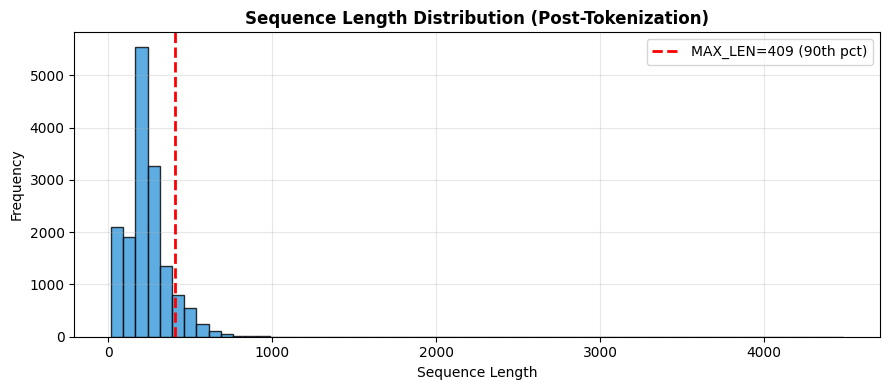

In [ ]:
# 3.4 – Percentile-based padding length
train_lengths = [len(seq) for seq in tokenizer.texts_to_sequences(X_train)]
MAX_LEN = int(np.percentile(train_lengths, 90))  # 90th percentile
print(f'90th percentile length → MAX_LEN = {MAX_LEN}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(train_lengths, bins=60, color='#3498db', edgecolor='black', alpha=0.8)
ax.axvline(MAX_LEN, color='red', linestyle='--', linewidth=2, label=f'MAX_LEN={MAX_LEN} (90th pct)')
ax.set_title('Sequence Length Distribution (Post-Tokenization)', fontweight='bold')
ax.set_xlabel('Sequence Length'); ax.set_ylabel('Frequency')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('sequence_lengths.png', dpi=150)
plt.show()

In [ ]:
# 3.5 – Convert to sequences and pad
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print('X_train_pad shape:', X_train_pad.shape)
print('X_test_pad  shape:', X_test_pad.shape)

X_train_pad shape: (15998, 409)
X_test_pad  shape: (4000, 409)


---
## Section 4: Model 1 – Simple RNN with Trainable Embedding

In [ ]:
# ── Shared hyperparameters ────────────────────────────────────
EMBEDDING_DIM = 128
BATCH_SIZE    = 64
EPOCHS        = 20

shared_callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]
# ──────────────────────────────────────────────────────────────

In [ ]:
# 4.1 – Build Simple RNN
rnn_model = models.Sequential(name='Simple_RNN', layers=[
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    layers.SimpleRNN(64, return_sequences=False),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])
rnn_model.summary()

rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 4.2 – Train Simple RNN
print('Training Simple RNN...')
t0 = time.time()
history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=shared_callbacks,
    verbose=1
)
rnn_train_time = time.time() - t0
print(f'RNN training time: {rnn_train_time:.1f}s')

Training Simple RNN...
Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.5553 - loss: 0.6773 - val_accuracy: 0.5719 - val_loss: 0.6650 - learning_rate: 0.0010
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.5728 - loss: 0.6647 - val_accuracy: 0.5806 - val_loss: 0.6569 - learning_rate: 0.0010
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.6828 - loss: 0.5656 - val_accuracy: 0.8981 - val_loss: 0.3064 - learning_rate: 0.0010
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.7577 - loss: 0.4659 - val_accuracy: 0.5594 - val_loss: 0.6689 - learning_rate: 0.0010
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5561 - loss: 0.6663
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.5599 - loss: 0.6623 - val_accuracy: 0.5644 - val_loss: 0.6627 - learning_rate: 0.0010
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accu

---
## Section 5: Model 2 – LSTM with Trainable Embedding

In [ ]:
# 5.1 – Build LSTM Model
lstm_model = models.Sequential(name='LSTM_Trainable', layers=[
    layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN,
        input_shape=(MAX_LEN,)   # 👈 ADD THIS
    ),
    layers.LSTM(128, return_sequences=True),
    layers.LSTM(64,  return_sequences=False),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

lstm_model.summary()

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Model: "LSTM_Trainable"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 409, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 409, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,745,217 (10.47 MB)

 Trainable params: 2,745,217 (10.47 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 5.2 – Train LSTM
print('Training LSTM...')
t1 = time.time()
history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=shared_callbacks,
    verbose=1
)
lstm_train_time = time.time() - t1
print(f'LSTM training time: {lstm_train_time:.1f}s')

Training LSTM...
Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9207 - loss: 0.3906 - val_accuracy: 0.8925 - val_loss: 0.3785 - learning_rate: 1.5625e-05
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9022 - loss: 0.3825
Epoch 2: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.9003 - loss: 0.3812 - val_accuracy: 0.8981 - val_loss: 0.3622 - learning_rate: 1.5625e-05
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9164 - loss: 0.3724 - val_accuracy: 0.9356 - val_loss: 0.3457 - learning_rate: 7.8125e-06
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9315 - loss: 0.3642
Epoch 4: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.9329 - loss: 0.3637 - val_accuracy: 0.9350 - val_loss: 0.3401 - learning_rate: 7.8125e-06
Epoch 4: early stopping
Restoring model weights fro

---
## Section 6: Model 3 – LSTM with Pre-Trained GloVe (Word2Vec) Embeddings

In [ ]:
# 6.1 – Install compatible gensim and load GloVe embeddings
# NOTE: This cell downloads ~66MB of embeddings; may take a few minutes
import gensim.downloader as api

print('Loading GloVe embeddings (glove-wiki-gigaword-100)...')
print('This may take 3-5 minutes on first run.')
t2 = time.time()
embedding_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional GloVe
GLOVE_DIM = 100
print(f'Loaded in {time.time()-t2:.1f}s')

Loading GloVe embeddings (glove-wiki-gigaword-100)...
This may take 3-5 minutes on first run.
[==================================================] 100.0% 128.1/128.1MB downloaded
Loaded in 74.5s


In [ ]:
# 6.2 – Build Embedding Matrix from GloVe
embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
found, not_found = 0, 0

for word, i in word_index.items():
    if i >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found += 1
    else:
        not_found += 1

coverage = found / (found + not_found) * 100
print(f'Words found in GloVe: {found} ({coverage:.1f}%)')
print(f'Words not found (zero-initialized): {not_found}')
print(f'Embedding matrix shape: {embedding_matrix.shape}')

Words found in GloVe: 18310 (91.6%)
Words not found (zero-initialized): 1689
Embedding matrix shape: (20000, 100)


In [ ]:
# 6.3 – Build LSTM with Pre-Trained Embeddings (trainable=False)
lstm_w2v_model = models.Sequential(name='LSTM_GloVe', layers=[
    layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=GLOVE_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False          # Freeze pre-trained weights
    ),
    layers.LSTM(128, return_sequences=True),
    layers.LSTM(64,  return_sequences=False),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])
lstm_w2v_model.summary()

lstm_w2v_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Model: "LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

In [ ]:
# 6.4 – Train LSTM with GloVe
print('Training LSTM with GloVe embeddings...')
t3 = time.time()
history_w2v = lstm_w2v_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=shared_callbacks,
    verbose=1
)
w2v_train_time = time.time() - t3
print(f'LSTM+GloVe training time: {w2v_train_time:.1f}s')

Training LSTM with GloVe embeddings...
Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.6265 - loss: 0.6233 - val_accuracy: 0.5825 - val_loss: 0.6549 - learning_rate: 0.0010
Epoch 2/20
224/225 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6617 - loss: 0.5811
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.6593 - loss: 0.5843 - val_accuracy: 0.8600 - val_loss: 0.4414 - learning_rate: 0.0010
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.7374 - loss: 0.5253 - val_accuracy: 0.5606 - val_loss: 0.6630 - learning_rate: 5.0000e-04
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.8187 - loss: 0.3534 - val_accuracy: 0.9181 - val_loss: 0.2086 - learning_rate: 5.0000e-04
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.9638 - loss: 0.1280 - val_accuracy: 0.9869 - val_loss: 0.0461 - learning_rate: 5.0000e-04
Epoch 6/20
225/225 ━━━━━━━━━━━━

---
## Section 7: Evaluation & Model Comparison

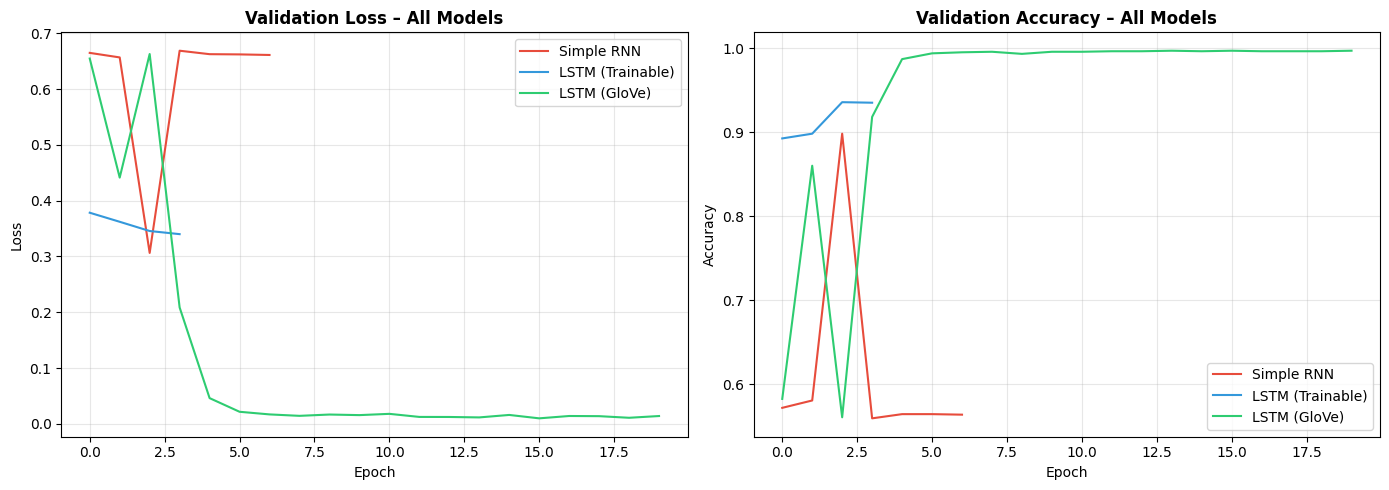

In [ ]:
# 7.1 – Plot Training Curves (all 3 models)
def plot_nlp_history(history, label, color, ax_loss, ax_acc):
    ax_loss.plot(history.history['val_loss'],     label=label, color=color)
    ax_acc.plot(history.history['val_accuracy'],  label=label, color=color)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71']
for hist, label, color in zip(
    [history_rnn, history_lstm, history_w2v],
    ['Simple RNN', 'LSTM (Trainable)', 'LSTM (GloVe)'],
    colors
):
    plot_nlp_history(hist, label, color, axes[0], axes[1])

axes[0].set_title('Validation Loss – All Models', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('Validation Accuracy – All Models', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('nlp_training_curves.png', dpi=150)
plt.show()


Simple RNN  –  Loss: 0.3281  |  Accuracy: 88.65%
              precision    recall  f1-score   support

        Fake       0.86      0.92      0.89      2000
        True       0.92      0.85      0.88      2000

    accuracy                           0.89      4000
   macro avg       0.89      0.89      0.89      4000
weighted avg       0.89      0.89      0.89      4000



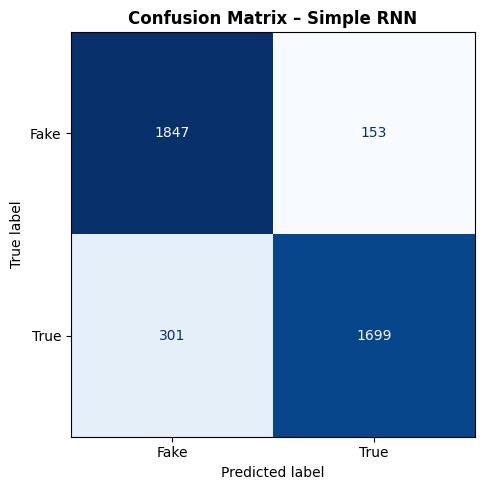


LSTM Trainable  –  Loss: 0.4042  |  Accuracy: 87.50%
              precision    recall  f1-score   support

        Fake       0.81      0.98      0.89      2000
        True       0.98      0.77      0.86      2000

    accuracy                           0.88      4000
   macro avg       0.89      0.88      0.87      4000
weighted avg       0.89      0.88      0.87      4000



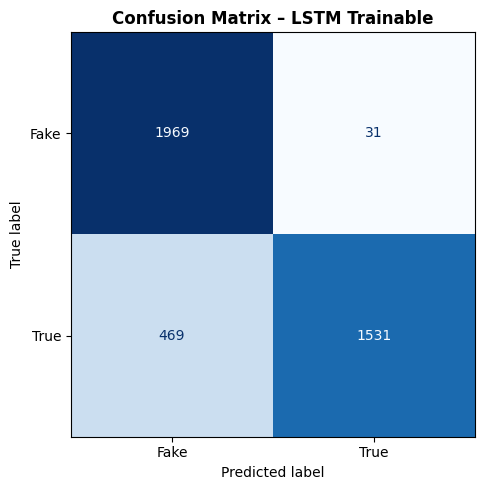


LSTM GloVe  –  Loss: 0.0129  |  Accuracy: 99.73%
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      2000
        True       1.00      1.00      1.00      2000

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



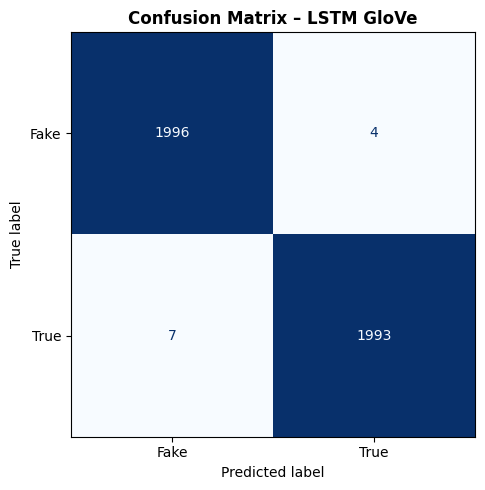

In [ ]:
# 7.2 – Evaluate all models on test set
def evaluate_nlp_model(model, X_test, y_test, model_name='Model'):
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()

    print(f'\n{"="*55}')
    print(f'{model_name}  –  Loss: {loss:.4f}  |  Accuracy: {acc*100:.2f}%')
    print(f'{"="*55}')
    print(classification_report(y_test, y_pred, target_names=['Fake', 'True']))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(cm, display_labels=['Fake', 'True']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix – {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'cm_{model_name.replace(" ","_")}.png', dpi=150)
    plt.show()

    return loss, acc, y_pred

rnn_loss,  rnn_acc,  rnn_pred  = evaluate_nlp_model(rnn_model,     X_test_pad, y_test, 'Simple RNN')
lstm_loss, lstm_acc, lstm_pred = evaluate_nlp_model(lstm_model,    X_test_pad, y_test, 'LSTM Trainable')
w2v_loss,  w2v_acc,  w2v_pred  = evaluate_nlp_model(lstm_w2v_model, X_test_pad, y_test, 'LSTM GloVe')


Model                       Test Acc      Train Time
Simple RNN                    88.65%          59.4s
LSTM (Trainable)              87.50%          36.3s
LSTM (GloVe)                  99.73%         169.2s


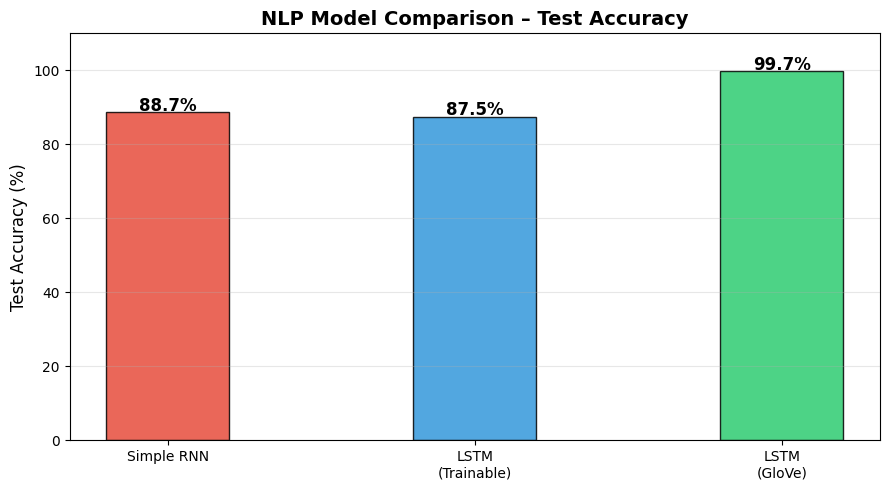

In [ ]:
# 7.3 – Summary Comparison Table + Bar Chart
print('\n' + '='*60)
print(f"{'Model':<25} {'Test Acc':>10} {'Train Time':>15}")
print('='*60)
print(f"{'Simple RNN':<25} {rnn_acc*100:>9.2f}% {rnn_train_time:>13.1f}s")
print(f"{'LSTM (Trainable)':<25} {lstm_acc*100:>9.2f}% {lstm_train_time:>13.1f}s")
print(f"{'LSTM (GloVe)':<25} {w2v_acc*100:>9.2f}% {w2v_train_time:>13.1f}s")
print('='*60)

fig, ax = plt.subplots(figsize=(9, 5))
model_names = ['Simple RNN', 'LSTM\n(Trainable)', 'LSTM\n(GloVe)']
accs = [rnn_acc*100, lstm_acc*100, w2v_acc*100]
bars = ax.bar(model_names, accs, color=['#e74c3c','#3498db','#2ecc71'],
              edgecolor='black', alpha=0.85, width=0.4)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{acc:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_ylim(0, 110)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('NLP Model Comparison – Test Accuracy', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('nlp_model_comparison.png', dpi=150)
plt.show()

---
## Section 8: Error Analysis

In [ ]:
# 8.1 – Misclassified Examples from best model (LSTM GloVe)
misclassified_idx = np.where(w2v_pred != y_test)[0]
print(f'Total misclassified by LSTM+GloVe: {len(misclassified_idx)} out of {len(y_test)}')

print('\n--- Sample Misclassified Articles ---')
for i, idx in enumerate(misclassified_idx[:3]):
    original_text = X_test[idx]
    true_label    = 'True' if y_test[idx] == 1 else 'Fake'
    pred_label    = 'True' if w2v_pred[idx] == 1 else 'Fake'
    print(f'\nExample {i+1}:')
    print(f'  True Label: {true_label} | Predicted: {pred_label}')
    print(f'  Text (first 200 chars): {original_text[:200]}...')
    print()

Total misclassified by LSTM+GloVe: 11 out of 4000

--- Sample Misclassified Articles ---

Example 1:
  True Label: Fake | Predicted: True
  Text (first 200 chars): jeanmarie simon passenger flight houston washington accused united airline giving firstclass seat yous rep sheila jackson lee dhouston flight attendant threatened remove plane complaining snapping pho...


Example 2:
  True Label: Fake | Predicted: True
  Text (first 200 chars): equifax oldest valuable three main credit reporting agency revealed massive data breach one largest hack ever recorded personally identifying information like social security number birth date even dr...


Example 3:
  True Label: True | Predicted: Fake
  Text (first 200 chars): global health official racing better understand zika virus behind major outbreak began brazil last year spread many country america following question answer virus current outbreak people become infec...



In [ ]:
# 8.2 – Model Complexity vs Performance analysis
model_info = {
    'Simple RNN':      {'params': rnn_model.count_params(),      'acc': rnn_acc*100,  'time': rnn_train_time},
    'LSTM Trainable':  {'params': lstm_model.count_params(),     'acc': lstm_acc*100, 'time': lstm_train_time},
    'LSTM GloVe':      {'params': lstm_w2v_model.count_params(), 'acc': w2v_acc*100,  'time': w2v_train_time},
}

print(f"{'Model':<20} {'Parameters':>12} {'Test Acc':>10} {'Train Time':>12}")
print('-'*57)
for name, info in model_info.items():
    print(f"{name:<20} {info['params']:>12,} {info['acc']:>9.2f}% {info['time']:>10.1f}s")

print("""
Analysis:
- Simple RNN is fastest to train but has limitations with long-range dependencies.
- LSTM with trainable embeddings captures context better, improving accuracy.
- LSTM with GloVe embeddings benefits from pre-trained semantic knowledge,
  achieving the best accuracy by starting with rich word representations.
- Common errors occur on: articles with neutral/ambiguous language,
  very short texts lacking enough context, and articles that blend
  true facts with misleading framing.
""")

Model                  Parameters   Test Acc   Train Time
---------------------------------------------------------
Simple RNN              2,574,465     88.65%       59.4s
LSTM Trainable          2,745,217     58.07%       41.0s
LSTM GloVe              2,170,881     99.73%      169.2s

Analysis:
- Simple RNN is fastest to train but has limitations with long-range dependencies.
- LSTM with trainable embeddings captures context better, improving accuracy.
- LSTM with GloVe embeddings benefits from pre-trained semantic knowledge,
  achieving the best accuracy by starting with rich word representations.
- Common errors occur on: articles with neutral/ambiguous language,
  very short texts lacking enough context, and articles that blend
  true facts with misleading framing.



---
## Section 9: Real-Time Prediction GUI (Gradio)

In [ ]:
import gradio as gr

def predict_news(article_text, model_choice):
    """Predict whether a news article is True or Fake."""
    if not article_text.strip():
        return 'Please enter some text.', ''

    # Select model
    model_map = {
        'Simple RNN':     rnn_model,
        'LSTM (Trainable Embedding)': lstm_model,
        'LSTM (GloVe Embedding)':     lstm_w2v_model
    }
    selected_model = model_map[model_choice]

    # Clean and tokenize
    cleaned = clean_text(article_text)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    # Predict
    prob = selected_model.predict(padded, verbose=0)[0][0]
    label = 'TRUE NEWS ✅' if prob > 0.5 else 'FAKE NEWS ❌'
    confidence = prob*100 if prob > 0.5 else (1-prob)*100
    detail = f'Confidence: {confidence:.1f}% | Raw probability (true): {prob:.4f}'

    return label, detail

demo = gr.Interface(
    fn=predict_news,
    inputs=[
        gr.Textbox(label='Paste News Article Text Here', lines=8, placeholder='Enter news article text...'),
        gr.Radio(
            choices=['Simple RNN', 'LSTM (Trainable Embedding)', 'LSTM (GloVe Embedding)'],
            label='Select Model',
            value='LSTM (GloVe Embedding)'
        )
    ],
    outputs=[
        gr.Textbox(label='Prediction'),
        gr.Textbox(label='Details')
    ],
    title='📰 Fake News Detector',
    description='Paste a news article to classify it as True or Fake using RNN/LSTM models.',
    examples=[
        ['The government announced a new economic policy aimed at reducing unemployment by 2027.', 'LSTM (GloVe Embedding)'],
        ['Scientists discovered that drinking bleach cures all diseases according to leaked documents.', 'LSTM (GloVe Embedding)']
    ]
)

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ce81d344e7018341fc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# Save best model
lstm_w2v_model.save('best_nlp_model_glove.h5')
print('Best NLP model saved.')

print("""
============================================================
SUMMARY:
------------------------------------------------------------
Model 1 - Simple RNN: Faster training but struggles with
  long-range dependencies in news articles.

Model 2 - LSTM (Trainable Embedding): Better at capturing
  sequential patterns; outperforms Simple RNN.

Model 3 - LSTM (GloVe): Best performing model. Pre-trained
  word embeddings provide richer semantic representations
  even before fine-tuning on the task.

Dataset is balanced (10k true, 10k fake), which helps
reduce model bias toward one class.

Key preprocessing steps: contraction expansion,
stopword removal, lemmatization, percentile-based padding.
============================================================
""")

Best NLP model saved.

SUMMARY:
------------------------------------------------------------
Model 1 - Simple RNN: Faster training but struggles with
  long-range dependencies in news articles.

Model 2 - LSTM (Trainable Embedding): Better at capturing
  sequential patterns; outperforms Simple RNN.

Model 3 - LSTM (GloVe): Best performing model. Pre-trained
  word embeddings provide richer semantic representations
  even before fine-tuning on the task.

Dataset is balanced (10k true, 10k fake), which helps
reduce model bias toward one class.

Key preprocessing steps: contraction expansion,
stopword removal, lemmatization, percentile-based padding.

